In [47]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Mean-Variance Portfolio Optimization and Efficient Frontier Analysis
---

## 1. Introduction

Portfolio optimization is a fundamental problem in quantative finance.
The goal is to allocate capital across multiple assets in a way that optimizes the tradeoff between expected return and risk.

In this project, we study a portfolio composed of 8 US stocks.
Although the assets are denominated in USD, performance will be evaluated from the perspective of a EUR-based investor.

We allow short-selling and include a risk-free asset in order to construct:

- The Global Minimum Variance Portfolio
- The Efficient Frontier
- The Maximum Sharpe (Tangency) Portfolio

The results will be compared against a simple equal-weight benchmark portfolio.


## 2. Research question

This project investigates how mean-variance portfolio optimization with short-selling performs relative to an equal-weight portfolio for a set of 8 US stocks, when evaluated of the perspective of a EUR-based investor including risk-free asset.

## 3. Assets

The portfolio consists of 8 large-cap US stocks across different sectors:

- Technology: AAPL, MSFT
- Healthcare: JNJ, PFE
- Consumer: KO, WMT
- Energy: XOM
- Finance: JPM

This diversified sector exposure allows meaningful covariance structure analysis and realistic portfolio construction.

## 4. Data description

We use 5 years of historical daily price data for the selected 8 US stocks

- Frequency: Daily
- Data type: Adjusted Close prices
- Period: Last 5 years
- Currency of assets: USD
- Base evaluation currency: EUR

Daily returns will be computed from adjusted closing prices.
The analysis will use log-returns for mathematical consistency.


## 5. Data download and currency conversion

We download 5 years of daily adjusted closing prices for the selected US stocks.

Since the assets are denominated in USD but evaluated from a EUR-based investor perspective, we convert prices into EUR using the EUR/USD exchange rate.


In [48]:
# Defining tickers
tickers = ["AAPL", "MSFT", "JNJ", "PFE", "KO", "WMT", "XOM", "JPM"]
fx_ticker = "EURUSD=X"

# Defining 5 years date range
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=5)

# Downloading stock prices in USD and extracting close prices
stocks_raw = yf.download(tickers, start=start_date, end=end_date, progress=False)
prices_usd = stocks_raw['Close'].dropna(how='all')

# Downloading EUR/USD rate
fx_raw = yf.download(fx_ticker, start=start_date, end=end_date, progress=False)
eurusd = fx_raw[("Close", fx_ticker)].dropna()

# Converting USD prices to EUR
eur_per_usd = 1 / eurusd
data = prices_usd.join(eur_per_usd.rename("EUR_per_USD"), how="inner")
prices_eur = data[tickers].mul(data["EUR_per_USD"], axis=0).dropna()

prices_eur.head()


,AAPL,MSFT,JNJ,PFE,KO,WMT,XOM,JPM
Date,,,,,,,,
2021-03-04,97.095157,180.538638,110.303738,22.109221,35.654302,32.958570,40.226879,110.024803
2021-03-05,98.817807,185.694288,113.266655,22.386098,36.512398,33.600717,42.037249,111.044724
2021-03-08,95.034074,182.962420,114.613102,22.439001,37.254516,33.395517,42.144126,112.913638
2021-03-09,99.514004,189.277195,115.547794,22.644692,36.920661,33.869212,41.752100,112.815384
2021-03-10,98.218951,187.445444,116.157481,22.871056,37.196705,34.598885,42.866907,114.819883


## 6. Return calculation

Portfolio operates on asset returns rather than prices.

We compute daily-log returns defined as:
$$ r_t =  \ln\left(\frac{P_t}{P_{t - 1}}\right) $$

where:

- $ P_t \text{ is the asset price at time } t $
- $ P_{t-1} \text{ is at previous time step}$

Log returns are preferred because:

- They are time additive
- They simplify mathematical derivations
- They are commonly used in quantative finance





In [49]:
log_returns = np.log(prices_eur / prices_eur.shift(1))
log_returns = log_returns.dropna()
log_returns.head()

,AAPL,MSFT,JNJ,PFE,KO,WMT,XOM,JPM
Date,,,,,,,,
2021-03-05,0.017586,0.028157,0.026507,0.012445,0.023782,0.019296,0.044021,0.009227
2021-03-08,-0.039042,-0.014821,0.011817,0.002360,0.020121,-0.006126,0.002539,0.016690
2021-03-09,0.046063,0.033932,0.008122,0.009125,-0.009002,0.014085,-0.009346,-0.000871
2021-03-10,-0.013099,-0.009725,0.005263,0.009947,0.007449,0.021315,0.026350,0.017612
2021-03-11,0.014005,0.017699,-0.002426,-0.008681,-0.013309,-0.002742,-0.009838,-0.007598


## 7. Estimation of Expected Returns and Covariance Matrix

Mean–variance portfolio optimization requires two main inputs:

- The expected return vector $\mu$
- The covariance matrix of asset returns $\Sigma$

These quantities are unknown in practice and must be estimated from historical data.

### Expected Return Vector

Let $r_t \in \mathbb{R}^n$ denote the vector of daily log-returns at time $t$, where $n$ is the number of assets.

We estimate the expected return using the sample mean:

$$\hat{\mu} = \frac{1}{T} \sum_{t=1}^{T} r_t$$

Here:
- $T$ is the number of observations
- $\hat{\mu} \in \mathbb{R}^n$
- Each element $\hat{\mu}_i$ represents the estimated expected return of asset $i$

### Covariance Matrix

Risk depends on how assets move together.
We estimate the covariance matrix as:

$$\hat{\Sigma} = \text{Cov}(r)$$

Each element of the matrix is:

$$\hat{\Sigma}_{ij} = \text{Cov}(r_i, r_j)$$

Where:
- $\hat{\Sigma} \in \mathbb{R}^{n \times n}$
- The diagonal elements $\hat{\Sigma}_{ii}$ represent variances
- The off-diagonal elements represent covariances

In [50]:
# Daily estimates
expected_daily_returns = log_returns.mean()
daily_covariance_matrix = log_returns.cov()

trading_days_per_year = 252

# Annualized expected returns
expected_annual_returns = expected_daily_returns * trading_days_per_year

# Annualized covariance matrix
annual_cov_matrix = daily_covariance_matrix * trading_days_per_year

expected_annual_returns, annual_cov_matrix.head()


(AAPL    0.169449
 MSFT    0.130430
 JNJ     0.130398
 PFE     0.005509
 KO      0.129339
 WMT     0.241201
 XOM     0.235600
 JPM     0.170381
 dtype: float64,
           AAPL      MSFT       JNJ       PFE        KO       WMT       XOM  \
 AAPL  0.083494  0.050046  0.013409  0.020157  0.018241  0.022448  0.021397   
 MSFT  0.050046  0.074384  0.008090  0.014458  0.012963  0.017820  0.010760   
 JNJ   0.013409  0.008090  0.033465  0.023536  0.017821  0.014295  0.011848   
 PFE   0.020157  0.014458  0.023536  0.069188  0.016923  0.012959  0.015538   
 KO    0.018241  0.012963  0.017821  0.016923  0.031214  0.017817  0.013702   
 
            JPM  
 AAPL  0.030250  
 MSFT  0.025155  
 JNJ   0.012625  
 PFE   0.016760  
 KO    0.013774  )

## 8. Global Minimum Variance Portfolio (GMVP)

The Global Minimum Variance Portfolio (GMVP) is the portfolio with the lowest possible variance among all fully-invested portfolios (i.e., portfolios whose weights sum to 1). It depends only on the covariance structure of asset returns and does not require specifying a target return.

Let:

- $ w \in \mathbb{R}^n$ be the vector of portfolio weights (one weight per asset)
- $ \Sigma \in \mathbb{R}^{n \times n} $ be the (annualized) covariance matrix of asset returns.

The portfolio variance is:

$$ \text{Var}(R_p) = w^T\Sigma w $$

### Optimization problem

Since we allow short-selling, weights may be negative. The GMVP is defined by:

$$ \min_{w} \quad w^{T} \Sigma w$$

subject to:

$$ 1^{T} w = 1 $$

where $1$ is a vector of ones

The constraint $ 1^{T} w = 1 $ enforces that the portfolio is fully invested (all capital allocated).

### Closed-form solution (Lagrange multipliers)
We solve the constrained optimization using a Lagrangian:

$$ \mathcal{L}(w,\lambda) = w^{T}\Sigma w - \lambda(1^{T}w - 1) $$

Taking derivatives with respect to $ w $ and setting them to zero:

$$ \nabla_w \mathcal{L} = 2\Sigma w - \lambda \mathbf{1} = 0 \quad \implies \quad \Sigma w = \frac{\lambda}{2}\mathbf{1}$$

Assuming $ \Sigma $ is invertible:

$$ w = \frac{\lambda}{2}\Sigma^{-1}\mathbf{1} $$

Apply the constraint $ 1^{T} w = 1 $:

$$
\mathbf{1}^{T} \left( \frac{\lambda}{2}\Sigma^{-1}\mathbf{1} \right) = 1
\quad \implies \quad
\frac{\lambda}{2} = \frac{1}{\mathbf{1}^{T}\Sigma^{-1}\mathbf{1}}
$$

Substitute back to obtain the GMVP weights:
$$ w_{\mathrm{GMVP}} = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}^{T}\Sigma^{-1}\mathbf{1}} $$

### Compute Global Minimum Variance Portfolio

In [51]:
# Number of assets
number_of_assets = len(tickers)

# Annual expected returns as Series
annual_expected_returns = expected_annual_returns.copy()

# Annual covariance as DataFrame (keep labels!)
annual_cov_df = daily_covariance_matrix * 252
annual_cov_df = annual_cov_df.loc[tickers, tickers]

# Vector of ones as Series
ones = pd.Series(1.0, index=tickers)

# Invert covariance matrix
inv_cov = pd.DataFrame(
    np.linalg.inv(annual_cov_df.values),
    index=tickers,
    columns=tickers
)

# GMVP weights:
numerator = inv_cov @ ones
denominator = float(ones.T @ inv_cov @ ones)
gmvp_weights = numerator / denominator

gmvp_weights_sorted = gmvp_weights.sort_values(ascending=False)

gmvp_weights_sorted

JNJ     0.286888
KO      0.268217
MSFT    0.144657
WMT     0.128679
XOM     0.102943
JPM     0.077396
PFE     0.043680
AAPL   -0.052460
dtype: float64

In [52]:
# Verifying Full Investment Constraint

gmvp_weights.sum() # should return approx 1.0

np.float64(0.9999999999999998)

### Expected Return and Risk of GMVP

In [53]:
# Expected annual return
gmvp_return = float(gmvp_weights.T @ annual_expected_returns)

# Portfolio variance
gmvp_variance = float(gmvp_weights.T @ annual_cov_df @ gmvp_weights)

# Portfolio volatility
gmvp_volatility = float(np.sqrt(gmvp_variance))

gmvp_return, gmvp_volatility

(0.15079707238931955, 0.14110892543517523)

### Comparing with Equal Weight Portfolio

In [54]:
# Equal-weight portfolio as Series with labels
equal_weight_weights = pd.Series(1/number_of_assets, index=tickers)

equal_weight_return = float(equal_weight_weights.T @ annual_expected_returns)
equal_weight_variance = float(equal_weight_weights.T @ annual_cov_df @ equal_weight_weights)
equal_weight_volatility = float(np.sqrt(equal_weight_variance))

comparison_table = pd.DataFrame({
    "Expected Annual Return": [gmvp_return, equal_weight_return],
    "Annual Volatility": [gmvp_volatility, equal_weight_volatility]
}, index=["Minimum Variance Portfolio", "Equal Weight Portfolio"])

comparison_table

,Expected Annual Return,Annual Volatility
Minimum Variance Portfolio,0.150797,0.141109
Equal Weight Portfolio,0.151538,0.153161


### Portfolio Weights

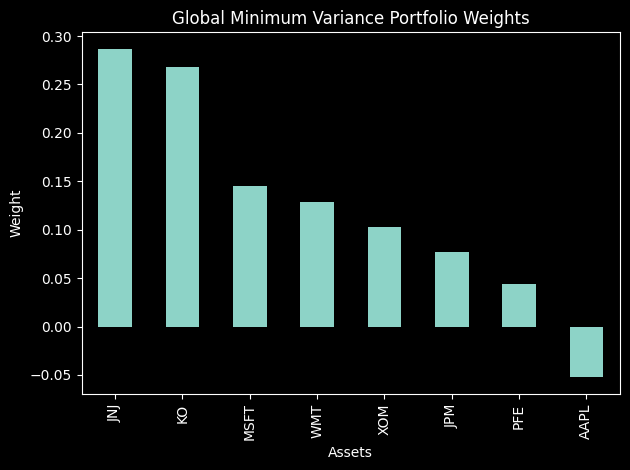

In [55]:
gmvp_weights_sorted.plot(
    kind="bar",
    title="Global Minimum Variance Portfolio Weights"
)

plt.ylabel("Weight")
plt.xlabel("Assets")
plt.tight_layout()
plt.show()

In [56]:
print("GMVP variance:", gmvp_variance)
print("EW variance:", equal_weight_variance)
print("GMVP <= EW ?", gmvp_variance <= equal_weight_variance)

GMVP variance: 0.019911728837469844
EW variance: 0.02345823963020717
GMVP <= EW ? True


## 9. Random Portfolio Simulation

To visualize the space of feasible portfolios and the risk-return tradeoff we generate a large number of random portfolios.

For each simulated portfolio we:

1. Randomly generate portfolio weights
2. Normalize weights, so that they sum to 1 (which means fully invested portfolio)
3. Compute expected annual return using the estimated mean vector
4. Compute the annual volatility using the estimated covariance matrix

Plotting all simulated portfolios in return-volatility in space produces a "cloud" of feasible portfolios.
The **lower boundry** of this cloud corresponds to portfolios with the **lowest volatility** for a given return, which motivates the construction of the **efficient frontier** in the next section.


## Long-only random portfolios

First, we simulate portfolios under the **long-only constraint**, meaning that portfolio weights must be non-negative and sum to one.

This corresponds to a realistic scenario for many investors who are not allowed to short-sell assets.

We generate random weights using a **Dirichlet distribution**, which guarantees that:

- all weights are positive
- weights sum exactly to 1

For each random portfolio we compute the expected annual return and volatility.

In [57]:
number_of_portfolios = 20000

long_only_returns = np.zeros(number_of_portfolios)
long_only_volatility = np.zeros(number_of_portfolios)

for i in range(number_of_portfolios):

    weights = np.random.dirichlet(np.ones(number_of_assets))
    weights = pd.Series(weights, index=tickers)

    portfolio_return = float(weights.T @ annual_expected_returns)
    portfolio_variance = float(weights.T @ annual_cov_df @ weights)
    portfolio_volatility = np.sqrt(portfolio_variance)

    long_only_returns[i] = portfolio_return
    long_only_volatility[i] = portfolio_volatility

## Long-short random portfolios

Next, we simulate portfolios that allow **short-selling**.

In this case weights may be negative, representing short positions in certain assets.
We generate random weights from a normal distribution and normalize them so that the weights still sum to one.

This produces portfolios that include both long and short exposures.

In [58]:
long_short_returns = np.zeros(number_of_portfolios)
long_short_volatility = np.zeros(number_of_portfolios)

for i in range(number_of_portfolios):

    weights = np.random.normal(0, 1, number_of_assets)

    weights = weights / np.sum(weights)
    weights = pd.Series(weights, index=tickers)

    portfolio_return = float(weights.T @ annual_expected_returns)
    portfolio_variance = float(weights.T @ annual_cov_df @ weights)
    portfolio_volatility = np.sqrt(portfolio_variance)

    long_short_returns[i] = portfolio_return
    long_short_volatility[i] = portfolio_volatility

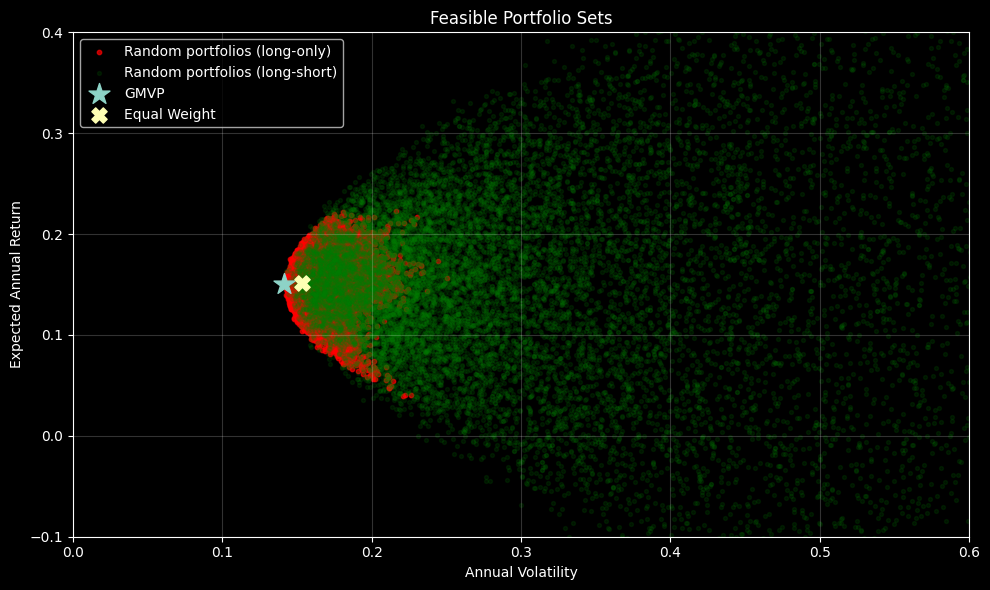

In [62]:
plt.figure(figsize=(10,6))

# Long-only portfolios
plt.scatter(
    long_only_volatility,
    long_only_returns,
    c='red',
    s=10,
    alpha=0.7,
    label="Random portfolios (long-only)"
)

# Long-short portfolios
plt.scatter(
    long_short_volatility,
    long_short_returns,
    c='green',
    s=8,
    alpha=0.15,
    label="Random portfolios (long-short)"
)

# GMVP
plt.scatter(
    gmvp_volatility,
    gmvp_return,
    marker="*",
    s=250,
    label="GMVP"
)

# Equal-weight
plt.scatter(
    equal_weight_volatility,
    equal_weight_return,
    marker="X",
    s=120,
    label="Equal Weight"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Feasible Portfolio Sets")

plt.xlim(0, 0.6)
plt.ylim(-0.1, 0.4)

plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows the set of feasible portfolios generated through random sampling.

Two portfolio sets are visible:

• **Long-only portfolios** form a constrained region because weights must be positive.
• **Long-short portfolios** occupy a wider region since negative weights allow additional hedging opportunities.

The **Global Minimum Variance Portfolio** appears near the left boundary of the feasible set, confirming that it achieves the lowest volatility among fully-invested portfolios.

In the next section, we move beyond random sampling and construct the **Efficient Frontier**, which represents the set of portfolios that minimize volatility for each target return level.